# Модуль 22. Поиск и проверяемость

Ноутбук к [модулю 22](https://drobyshevdev.github.io/lemma/modules/22-retrieval-and-verifiability/).

Три вещи, из которых складывается ответ, которому можно верить:

1. **Семантический поиск** скалярным произведением и его слепое пятно на точном слове; **гибрид** с лексикой закрывает и то, и другое.
2. **Реранкер:** дешёвый поиск даёт полноту, переупорядочивание верха даёт точность.
3. **Проверка цитат:** сверяем каждое утверждение ответа с источником и ловим выдуманное.

Только `numpy` и `matplotlib`, всё детерминировано. **Читайте дважды:** сначала целиком, потом ломая.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(22)

ACCENT = "#6f6af0"; GOLD = "#c99a3a"; BAD = "#d0705f"; GREY = "#7a7a86"
plt.rcParams["figure.dpi"] = 110

## 1. Семантика, лексика и гибрид

Документ — это две вещи: **эмбеддинг** (вектор смысла из [модуля 17](https://drobyshevdev.github.io/lemma/modules/17-collaborative-filtering/)) и **набор слов**. Семантический поиск меряет близость эмбеддингов скалярным произведением; лексический считает совпадение слов.

Соберём коллекцию: `K` тем, у каждого документа — эмбеддинг своей темы и один **редкий токен** (код товара, имя функции), который встречается ровно в одном документе.

In [2]:
D, K, N = 24, 6, 30
centroids = rng.normal(size=(K, D))
centroids /= np.linalg.norm(centroids, axis=1, keepdims=True)

def unit(v):
    return v / (np.linalg.norm(v) + 1e-9)

topics = rng.integers(0, K, size=N)
doc_emb = np.array([unit(centroids[t] + 0.15 * rng.normal(size=D)) for t in topics])
# редкий токен: у каждого документа свой уникальный код
doc_rare = ["code_%02d" % i for i in range(N)]
global_mean = unit(doc_emb.mean(axis=0))
print("Документов:", N, "| тем:", K, "| размерность эмбеддинга:", D)

Документов: 30 | тем: 6 | размерность эмбеддинга: 24


Два вида запросов.

- **Смысловой** запрос — перефраз документа: его эмбеддинг близок к нужному документу, но **общих слов нет** (лексика бессильна).
- **Точный** запрос — по редкому коду: эмбеддинг размытый, близкий ко многим (семантика не различает), но код указывает на документ однозначно.

Так устроена жизнь: часть вопросов — «про смысл», часть — «дай мне вот это по коду».

In [3]:
def make_queries(n_each=12):
    qs = []
    gold_docs = rng.choice(N, size=2 * n_each, replace=False)
    for i, g in enumerate(gold_docs):
        if i < n_each:                                   # смысловой запрос
            q_emb = unit(doc_emb[g] + 0.20 * rng.normal(size=D))
            q_rare = "code_zzz"                           # ни в одном документе
            qs.append(("sem", g, q_emb, q_rare))
        else:                                            # точный запрос
            q_emb = unit(global_mean + 0.20 * rng.normal(size=D))
            q_rare = doc_rare[g]                          # ровно код нужного документа
            qs.append(("lex", g, q_emb, q_rare))
    return qs

queries = make_queries()
print("Запросов:", len(queries), "(поровну смысловых и точных)")

Запросов: 24 (поровну смысловых и точных)


In [4]:
def normise(x):
    x = np.asarray(x, float)
    lo, hi = x.min(), x.max()
    return (x - lo) / (hi - lo) if hi > lo else np.zeros_like(x)

def scores(q_emb, q_rare):
    sem = doc_emb @ q_emb                                  # скалярное произведение
    lex = np.array([1.0 if q_rare == r else 0.0 for r in doc_rare])
    return sem, lex

def recall_at1(mode):
    hits = 0
    for kind, g, q_emb, q_rare in queries:
        sem, lex = scores(q_emb, q_rare)
        if mode == "sem":    s = sem
        elif mode == "lex":  s = lex
        else:                s = normise(sem) + normise(lex)   # гибрид
        if int(np.argmax(s)) == g:
            hits += 1
    return hits / len(queries)

r_sem, r_lex, r_hyb = recall_at1("sem"), recall_at1("lex"), recall_at1("hybrid")
print("recall@1  семантика: %.2f | лексика: %.2f | гибрид: %.2f" % (r_sem, r_lex, r_hyb))

recall@1  семантика: 0.46 | лексика: 0.50 | гибрид: 0.96


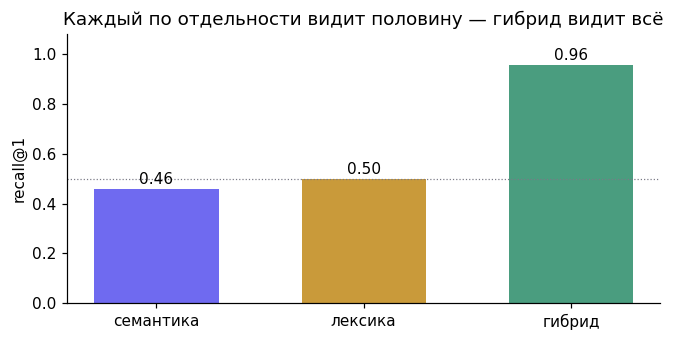

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 3.2))
names = ["семантика", "лексика", "гибрид"]
vals = [r_sem, r_lex, r_hyb]
cols = [ACCENT, GOLD, "#4a9d7f"]
bars = ax.bar(names, vals, color=cols, width=0.6)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, "%.2f" % v, ha="center", fontsize=10)
ax.set_ylim(0, 1.08); ax.set_ylabel("recall@1")
ax.set_title("Каждый по отдельности видит половину — гибрид видит всё")
ax.axhline(0.5, color=GREY, lw=0.8, ls=":")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

Семантика находит смысловые запросы и теряет точные; лексика — наоборот. Каждая по отдельности видит примерно половину. Гибрид — сумма нормированных баллов — закрывает слепое пятно каждого и находит почти всё.

**Сломайте:** уберите нормировку (`sem + lex` вместо `normise(...)`). Семантические баллы (порядка 1.0) задавят лексические (0/1), и гибрид просядет до чистой семантики. Масштаб решает — складывать можно только сопоставимое.

## 2. Реранкер: полнота дёшево, точность дорого

Дешёвый поиск быстрый, но шумный: он хорошо вытаскивает нужное **куда-то в топ-N** (высокая полнота), но плохо ставит его **на первое место**. Реранкер — медленная точная модель — переупорядочивает только этот топ. Это ранжирование из [модуля 18](https://drobyshevdev.github.io/lemma/modules/18-neural-recommenders-and-ranking/): важно не «нашлось ли», а «наверху ли».

Модель: у каждого запроса есть истинная релевантность документов. Дешёвый поиск видит её сквозь **большой** шум, реранкер — сквозь **малый**.

In [6]:
M = 40                                   # документов на запрос
Q = 400                                  # запросов
def trial(cheap_sd, rerank_sd, topN=10):
    p1c = p3c = p1r = p3r = rec = 0
    for _ in range(Q):
        rel = np.zeros(M); rel[0] = 1.0          # документ 0 -- золотой
        rel[1:6] = 0.5                            # трудные негативы
        cheap = rel + rng.normal(0, cheap_sd, M)  # дешёвый шумный балл
        top = np.argsort(-cheap)[:topN]           # дешёвый поиск: топ-N
        rec += 0 in top                           # полнота@N: золото попало в топ?
        # порядок внутри топа: дёшево против реранка
        order_c = top[np.argsort(-cheap[top])]
        rerank = rel[top] + rng.normal(0, rerank_sd, len(top))
        order_r = top[np.argsort(-rerank)]
        p1c += order_c[0] == 0;  p3c += 0 in order_c[:3]
        p1r += order_r[0] == 0;  p3r += 0 in order_r[:3]
    n = Q
    return dict(recall=rec/n, p1c=p1c/n, p3c=p3c/n, p1r=p1r/n, p3r=p3r/n)

res = trial(cheap_sd=0.55, rerank_sd=0.12)
print("полнота@10 (дешёвый поиск): %.2f" % res["recall"])
print("precision@1  дёшево: %.2f -> реранк: %.2f" % (res["p1c"], res["p1r"]))
print("precision@3  дёшево: %.2f -> реранк: %.2f" % (res["p3c"], res["p3r"]))

полнота@10 (дешёвый поиск): 0.81
precision@1  дёшево: 0.30 -> реранк: 0.81
precision@3  дёшево: 0.54 -> реранк: 0.81


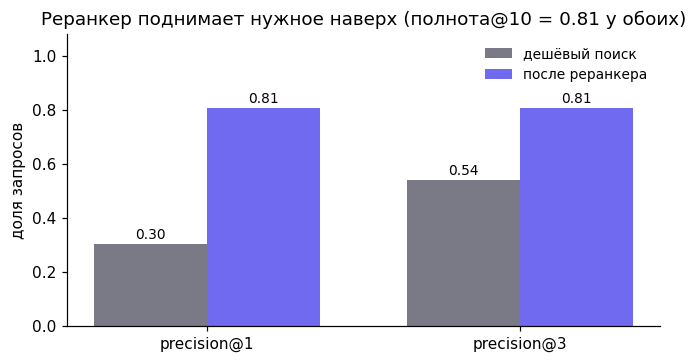

In [7]:
fig, ax = plt.subplots(figsize=(6.2, 3.4))
ks = ["precision@1", "precision@3"]
x = np.arange(len(ks)); w = 0.36
before = [res["p1c"], res["p3c"]]
after = [res["p1r"], res["p3r"]]
ax.bar(x - w/2, before, w, label="дешёвый поиск", color=GREY)
ax.bar(x + w/2, after,  w, label="после реранкера", color=ACCENT)
for i, (b, a) in enumerate(zip(before, after)):
    ax.text(i - w/2, b + 0.02, "%.2f" % b, ha="center", fontsize=9)
    ax.text(i + w/2, a + 0.02, "%.2f" % a, ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(ks)
ax.set_ylim(0, 1.08); ax.set_ylabel("доля запросов")
ax.set_title("Реранкер поднимает нужное наверх (полнота@10 = %.2f у обоих)" % res["recall"])
ax.legend(frameon=False, fontsize=9)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

Полнота у обоих одна: реранкер работает по тому же топ-N и не может вытащить то, чего дешёвый поиск не нашёл. Но точность наверху он поднимает заметно — золото чаще оказывается на первом месте.

**Сломайте:** сделайте `rerank_sd` равным `cheap_sd`. Реранкер станет не точнее дешёвого поиска, и прирост исчезнет — реранкер полезен ровно настолько, насколько он менее шумный.

## 3. Проверка цитат

RAG положил документы в контекст, но модель всё ещё может выдумать. Лечение — **привязать каждое утверждение к источнику и сверить**. Возьмём ответ из четырёх утверждений, каждое со своим источником. Одно — выдумано: модель написала «98%», источник говорит «91%».

Проверка простая и честная: вытащим из утверждения его **опору** (число) и посмотрим, есть ли она в источнике.

In [8]:
import re

answer = [
    ("Модель поддерживает 12 языков.",   "…поддерживает 12 языков, включая русский…"),
    ("Код открыт под лицензией MIT.",     "…исходники доступны под лицензией MIT…"),
    ("Точность на тесте — 98%.",          "…точность на тесте составила 91%…"),   # выдумка
    ("Ноутбуки считаются на CPU.",        "…все примеры запускаются на CPU за секунды…"),
]

def support(claim, source):
    nums = re.findall(r"\d+", claim)
    if nums:                                   # есть число -- проверяем именно его
        return all(n in source for n in nums)
    key = [w for w in re.findall(r"[A-Za-zА-Яа-я]+", claim) if len(w) >= 3]
    return sum(w.lower() in source.lower() for w in key) >= max(1, len(key) // 2)

for claim, src in answer:
    ok = support(claim, src)
    print(("[OK] " if ok else "[!!] ") + claim + ("" if ok else "  <- не подтверждается"))

[OK] Модель поддерживает 12 языков.
[OK] Код открыт под лицензией MIT.
[!!] Точность на тесте — 98%.  <- не подтверждается
[OK] Ноутбуки считаются на CPU.


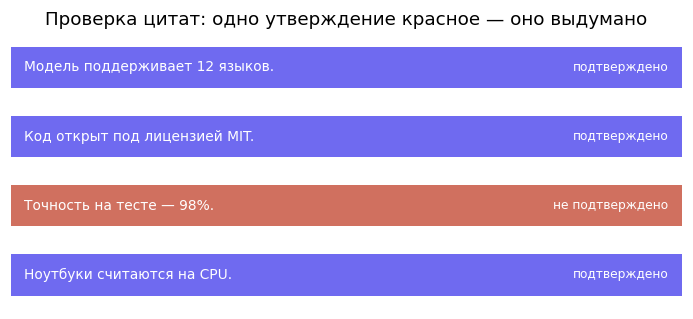

Поймано выдумок: 1 из 4


In [9]:
flags = [support(c, s) for c, s in answer]
fig, ax = plt.subplots(figsize=(6.4, 3.0))
y = np.arange(len(answer))[::-1]
cols = [ACCENT if f else BAD for f in flags]
ax.barh(y, [1] * len(answer), color=cols, height=0.6)
for yi, (claim, _), f in zip(y, answer, flags):
    ax.text(0.02, yi, claim, va="center", fontsize=9, color="white")
    ax.text(0.98, yi, "подтверждено" if f else "не подтверждено",
            va="center", ha="right", fontsize=8, color="white")
ax.set_xlim(0, 1); ax.axis("off")
ax.set_title("Проверка цитат: одно утверждение красное — оно выдумано")
plt.tight_layout(); plt.show()
print("Поймано выдумок:", flags.count(False), "из", len(answer))

Проверка ловит ровно одно утверждение — то, где число ответа расходится с источником. Три остальных подтверждаются.

Теперь главное: **проверка не ведётся на убедительность**. Перепишем выдумку так, чтобы она звучала солиднее всех — длиннее, с оговорками, тоном эксперта. Источник тот же.

In [10]:
convincing = (
    "Как показывают тщательно проведённые замеры на отложенной выборке, "
    "итоговая точность модели достигает внушительных 98%.",
    "…точность на тесте составила 91%…")

print("Убедительная формулировка выдумки:")
print(" ", convincing[0])
print("  подтверждается источником:", support(*convincing))
print()
print("Беглость выросла, опора — нет. Число 98 в источнике по-прежнему отсутствует,")
print("поэтому проверка ставит тот же вердикт: не подтверждено.")

Убедительная формулировка выдумки:
  Как показывают тщательно проведённые замеры на отложенной выборке, итоговая точность модели достигает внушительных 98%.
  подтверждается источником: False

Беглость выросла, опора — нет. Число 98 в источнике по-прежнему отсутствует,
поэтому проверка ставит тот же вердикт: не подтверждено.


Формулировка стала убедительнее, вердикт — нет. Проверка смотрит на **сцепку с источником**, а не на тон: число `98` в источнике по-прежнему отсутствует.

В этом весь модуль. Беглость и правда звучат одинаково, поэтому доверять можно не тону ответа, а его привязке к источнику. Ответ, который нельзя выдумать, — это ответ, каждое слово которого указывает на строку, которую можно открыть.

## Что дальше

- Замените проверку числа на проверку по эмбеддингам: утверждение подтверждено, если ближайший к нему фрагмент источника достаточно близок. Где это точнее совпадения слов, а где — хуже?
- Сделайте гибрид взвешенным (`α·sem + (1-α)·lex`) и найдите `α`, где recall@1 максимум.
- В [модуле 23](https://drobyshevdev.github.io/lemma/programme/) эта проверка станет одним из автоматических тестов на агента, а трейс из модуля 21 — тем, что тест читает.